In [28]:
# ══════════════════════════════════════════════
# CELL 1 — GPU CHECK
# ══════════════════════════════════════════════
import tensorflow as tf
import os, gc
import numpy as np
 
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("❌ NO GPU — go to Settings → Accelerator → GPU P100 → Save → restart!")
else:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f"✅ GPU ready: {gpus[0].name}")
 
print("TF:", tf.__version__)

✅ GPU ready: /physical_device:GPU:0
TF: 2.19.0


In [29]:
# ══════════════════════════════════════════════
# CELL 2 — IMPORTS
# ══════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.ndimage import convolve
from sklearn.metrics import classification_report, confusion_matrix
import random
 
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, AveragePooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization,
    Input, Add, Activation
)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.regularizers import l2
 
print("Imports OK ✅")

Imports OK ✅


In [30]:
# ══════════════════════════════════════════════
# CELL 3 — CONFIG
# ══════════════════════════════════════════════
IMG_SIZE   = 256   # keep 256 — PVD patterns need full resolution
BATCH_SIZE = 8     # small batch = low RAM per step
EPOCHS     = 50
 
BASE        = '/kaggle/input/datasets/petrdufek/stego-pvd-dataset/Stego-pvd-dataset'
TRAIN_CLEAN = os.path.join(BASE, 'train/cleanTrain')
TRAIN_STEGO = os.path.join(BASE, 'train/stegoTrain')
VAL_CLEAN   = os.path.join(BASE, 'val/cleanVal')
VAL_STEGO   = os.path.join(BASE, 'val/stegoVal')
TEST_CLEAN  = os.path.join(BASE, 'test/cleanTest')
TEST_STEGO  = os.path.join(BASE, 'test/stegoTest')
MODEL_BEST  = '/kaggle/working/best_model.keras'
MODEL_FINAL = '/kaggle/working/final_model.keras'
 
SUPPORTED = {'.png', '.jpg', '.jpeg', '.bmp'}
 
print("Paths:")
for p in [TRAIN_CLEAN, TRAIN_STEGO, VAL_CLEAN, VAL_STEGO, TEST_CLEAN, TEST_STEGO]:
    n = len([f for f in os.listdir(p)
             if os.path.splitext(f)[1].lower() in SUPPORTED]) if os.path.exists(p) else 0
    print(f"  {'✅' if os.path.exists(p) else '❌'}  {os.path.basename(p):15s} {n} images")
 

Paths:
  ✅  cleanTrain      4000 images
  ✅  stegoTrain      3995 images
  ✅  cleanVal        2000 images
  ✅  stegoVal        2000 images
  ✅  cleanTest       2000 images
  ✅  stegoTest       2000 images


In [31]:
# ══════════════════════════════════════════════
# CELL 4 — SRM FILTER BANK
# ══════════════════════════════════════════════
SRM_KERNELS = [
    np.array([[-1,-1,-1],[-1, 8,-1],[-1,-1,-1]], np.float32) / 8.0,   # Laplacian
    np.array([[ 0, 0, 0],[-1, 2,-1],[ 0, 0, 0]], np.float32) / 2.0,   # Horizontal
    np.array([[ 0,-1, 0],[ 0, 2, 0],[ 0,-1, 0]], np.float32) / 2.0,   # Vertical
    np.array([[-1, 0, 0],[ 0, 2, 0],[ 0, 0,-1]], np.float32) / 2.0,   # Diag 1
    np.array([[ 0, 0,-1],[ 0, 2, 0],[-1, 0, 0]], np.float32) / 2.0,   # Diag 2
    np.array([[ 0,-1, 0],[-1, 4,-1],[ 0,-1, 0]], np.float32) / 4.0,   # 5-point
]
 
def apply_srm(arr):
    """arr: float32 H×W×3 in [0,1] → filtered H×W×3"""
    out = np.mean([
        np.stack([convolve(arr[:,:,c], k) for c in range(3)], axis=-1)
        for k in SRM_KERNELS
    ], axis=0)
    out -= out.min()
    mx = out.max()
    if mx > 0: out /= mx
    return out.astype(np.float32)
 
def load_image(path):
    img = Image.open(path).convert("RGB")
    if img.size != (IMG_SIZE, IMG_SIZE):
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    return apply_srm(arr)
 
print("SRM filter bank ready ✅")

SRM filter bank ready ✅


In [32]:
# ══════════════════════════════════════════════
# CELL 5 — FILE LIST BUILDER  (no images in RAM!)
# ══════════════════════════════════════════════
def get_file_list(clean_dir, stego_dir, shuffle=True):
    """Returns list of (filepath, label) — NO images loaded yet"""
    pairs = []
    for f in os.listdir(clean_dir):
        if os.path.splitext(f)[1].lower() in SUPPORTED:
            pairs.append((os.path.join(clean_dir, f), 0))
    for f in os.listdir(stego_dir):
        if os.path.splitext(f)[1].lower() in SUPPORTED:
            pairs.append((os.path.join(stego_dir, f), 1))
    if shuffle:
        random.seed(42)
        random.shuffle(pairs)
    return pairs
 
train_files = get_file_list(TRAIN_CLEAN, TRAIN_STEGO, shuffle=True)
val_files   = get_file_list(VAL_CLEAN,   VAL_STEGO,   shuffle=False)
test_files  = get_file_list(TEST_CLEAN,  TEST_STEGO,  shuffle=False)
 
print(f"Train files : {len(train_files)}")
print(f"Val   files : {len(val_files)}")
print(f"Test  files : {len(test_files)}")
print("✅ No images loaded yet — RAM safe!")
 

Train files : 7995
Val   files : 4000
Test  files : 4000
✅ No images loaded yet — RAM safe!


In [33]:
# ══════════════════════════════════════════════
# CELL 6 — tf.data GENERATOR  (key fix for RAM)
# ══════════════════════════════════════════════
def make_dataset_from_files(file_list, augment=False, shuffle=False):
    """
    Builds tf.data pipeline that loads images ON DEMAND.
    Only BATCH_SIZE images in RAM at any time → no crash.
    """
    paths  = [p for p, _ in file_list]
    labels = [l for _, l in file_list]
 
    path_ds  = tf.data.Dataset.from_tensor_slices(paths)
    label_ds = tf.data.Dataset.from_tensor_slices(
        tf.cast(labels, tf.float32))
 
    def load_and_filter(path):
        # Load image on-the-fly inside tf.data
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3,
                                    expand_animations=False)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32) / 255.0
 
        # Apply SRM via tf.numpy_function (runs scipy convolve)
        img = tf.numpy_function(
            func=apply_srm,
            inp=[img],
            Tout=tf.float32
        )
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img
 
    img_ds = path_ds.map(load_and_filter,
                         num_parallel_calls=tf.data.AUTOTUNE)
    ds = tf.data.Dataset.zip((img_ds, label_ds))
 
    if shuffle:
        ds = ds.shuffle(buffer_size=500, seed=42)
 
    if augment:
        def aug(img, lbl):
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            return img, lbl
        ds = ds.map(aug, num_parallel_calls=tf.data.AUTOTUNE)
 
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
 
train_ds = make_dataset_from_files(train_files, augment=True,  shuffle=True)
val_ds   = make_dataset_from_files(val_files,   augment=False, shuffle=False)
test_ds  = make_dataset_from_files(test_files,  augment=False, shuffle=False)
 
print("✅ Generator pipeline ready — images load on demand")
print(f"Steps per epoch: {len(train_files) // BATCH_SIZE}")
 

✅ Generator pipeline ready — images load on demand
Steps per epoch: 999


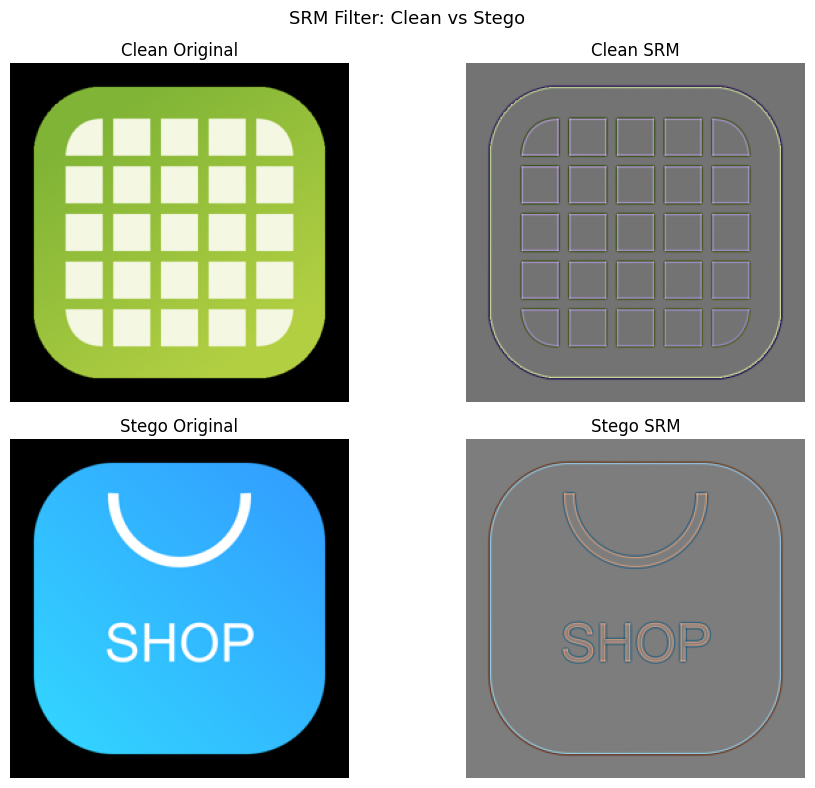

In [34]:
# ══════════════════════════════════════════════
# CELL 7 — VISUALIZE SRM
# ══════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("SRM Filter: Clean vs Stego", fontsize=13)
for row, (folder, name) in enumerate([(TRAIN_CLEAN,'Clean'),(TRAIN_STEGO,'Stego')]):
    files = [f for f in os.listdir(folder) if f.lower().endswith('.png')]
    orig  = np.array(Image.open(os.path.join(folder,files[0]))
                     .convert("RGB").resize((256,256)), dtype=np.float32)/255.0
    axes[row][0].imshow(orig);            axes[row][0].set_title(f"{name} Original"); axes[row][0].axis('off')
    axes[row][1].imshow(apply_srm(orig)); axes[row][1].set_title(f"{name} SRM");      axes[row][1].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/srm_comparison.png', dpi=100)
plt.show()

In [35]:
# ══════════════════════════════════════════════
# IMPROVED MODEL — Fixed Residual Blocks + TLU
# ══════════════════════════════════════════════
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add
from tensorflow.keras.layers import AveragePooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def tlu(x):
    """Truncated Linear Unit - helps focus on weak stego noise"""
    return tf.clip_by_value(x, -3.0, 3.0)

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# First layer after SRM (rich high-pass features)
x = Conv2D(30, (5, 5), padding='same', use_bias=False)(inputs)
x = Activation(tlu)(x)
x = BatchNormalization()(x)

# Residual Block 1 (32 filters)
shortcut = Conv2D(32, (1, 1), padding='same')(x)   # 1x1 projection to match channels
x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = Add()([x, shortcut])
x = Activation('relu')(x)
x = AveragePooling2D((2, 2))(x)

# Residual Block 2 (64 filters)
shortcut = Conv2D(64, (1, 1), padding='same')(x)
x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = Add()([x, shortcut])
x = Activation('relu')(x)
x = AveragePooling2D((2, 2))(x)

# Residual Block 3 (128 filters)
shortcut = Conv2D(128, (1, 1), padding='same')(x)
x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = Add()([x, shortcut])
x = Activation('relu')(x)
x = AveragePooling2D((2, 2))(x)

x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0008),   # slightly lower LR for stability
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 256, 256,  │      2,250 │ input_layer_3[0]… │
│                     │ 30)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 256, 256,  │          0 │ conv2d_27[0][0]   │
│ (Activation)        │ 30)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        120 │ activation_19[0]… │
│ (BatchNormalizatio… │ 30)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 256, 256,  │      8,672 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 256, 256,  │        992 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_28[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 256, 256,  │          0 │ add_9[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_… │ (None, 128, 128,  │          0 │ activation_20[0]… │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 128, 128,  │     18,496 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 128, 128,  │      2,112 │ average_pooling2

 Total params: 376,419 (1.44 MB)

 Trainable params: 375,463 (1.43 MB)

 Non-trainable params: 956 (3.73 KB)

In [36]:
# ══════════════════════════════════════════════
# CELL 9 — TRAIN
# ══════════════════════════════════════════════
print("\n" + "="*50)
print("TRAINING 🚀  (images load on-demand — no RAM crash)")
print("="*50)
 
callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5,
                      mode='max', min_lr=1e-7, verbose=1),
    ModelCheckpoint(MODEL_BEST, monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1)
]
 
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)
print("Training done ✅")


TRAINING 🚀  (images load on-demand — no RAM crash)
Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4906 - auc: 0.4846 - loss: 0.7359
Epoch 1: val_auc improved from -inf to 0.56936, saving model to /kaggle/working/best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 137s 118ms/step - accuracy: 0.4906 - auc: 0.4846 - loss: 0.7358 - val_accuracy: 0.5480 - val_auc: 0.5694 - val_loss: 0.6907 - learning_rate: 8.0000e-04
Epoch 2/50
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5013 - auc: 0.5003 - loss: 0.6961
Epoch 2: val_auc did not improve from 0.56936
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 119s 115ms/step - accuracy: 0.5013 - auc: 0.5003 - loss: 0.6961 - val_accuracy: 0.4965 - val_auc: 0.5416 - val_loss: 0.6904 - learning_rate: 8.0000e-04
Epoch 3/50
 998/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4987 - auc: 0.4994 - loss: 0.6951
Epoch 3: val_auc did not improve from 0.56936
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 113s 109ms/step - accuracy: 0.4987 - auc: 0.4994 - lo

In [37]:
# ══════════════════════════════════════════════
# CELL 10 — EVALUATE
# ══════════════════════════════════════════════
t_loss, t_acc, t_auc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy : {t_acc*100:.2f}%")
print(f"Test AUC      : {t_auc:.4f}")
 
y_pred = (model.predict(test_ds).flatten() > 0.5).astype(int)
y_true = np.array([l for _, l in test_files])
print(classification_report(y_true, y_pred, target_names=["Clean","Stego"]))
 


Test Accuracy : 95.78%
Test AUC      : 0.9915
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step
              precision    recall  f1-score   support

       Clean       0.94      0.97      0.96      2000
       Stego       0.97      0.94      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000




TEST SET EVALUATION

Test Accuracy : 95.78%
Test AUC      : 0.9915
Test Loss     : 0.1246

Classification Report:
              precision    recall  f1-score   support

       Clean       0.94      0.97      0.96      2000
       Stego       0.97      0.94      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



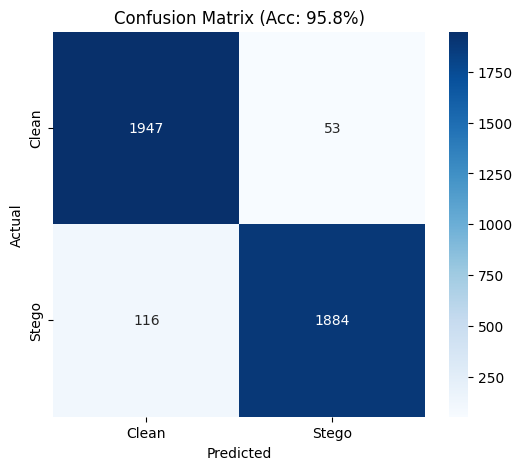

In [39]:
# ══════════════════════════════════════════════
# FINAL TEST EVALUATION (Fixed)
# ══════════════════════════════════════════════
print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

t_loss, t_acc, t_auc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy : {t_acc*100:.2f}%")
print(f"Test AUC      : {t_auc:.4f}")
print(f"Test Loss     : {t_loss:.4f}")

# Predict
y_pred_prob = model.predict(test_ds, verbose=0).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Use the correct variable (you already have y_true from earlier)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Clean", "Stego"]))

# Confusion Matrix (optional but useful)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Clean", "Stego"], 
            yticklabels=["Clean", "Stego"])
plt.title(f"Confusion Matrix (Acc: {t_acc*100:.1f}%)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Saved → /kaggle/working/final_model.keras


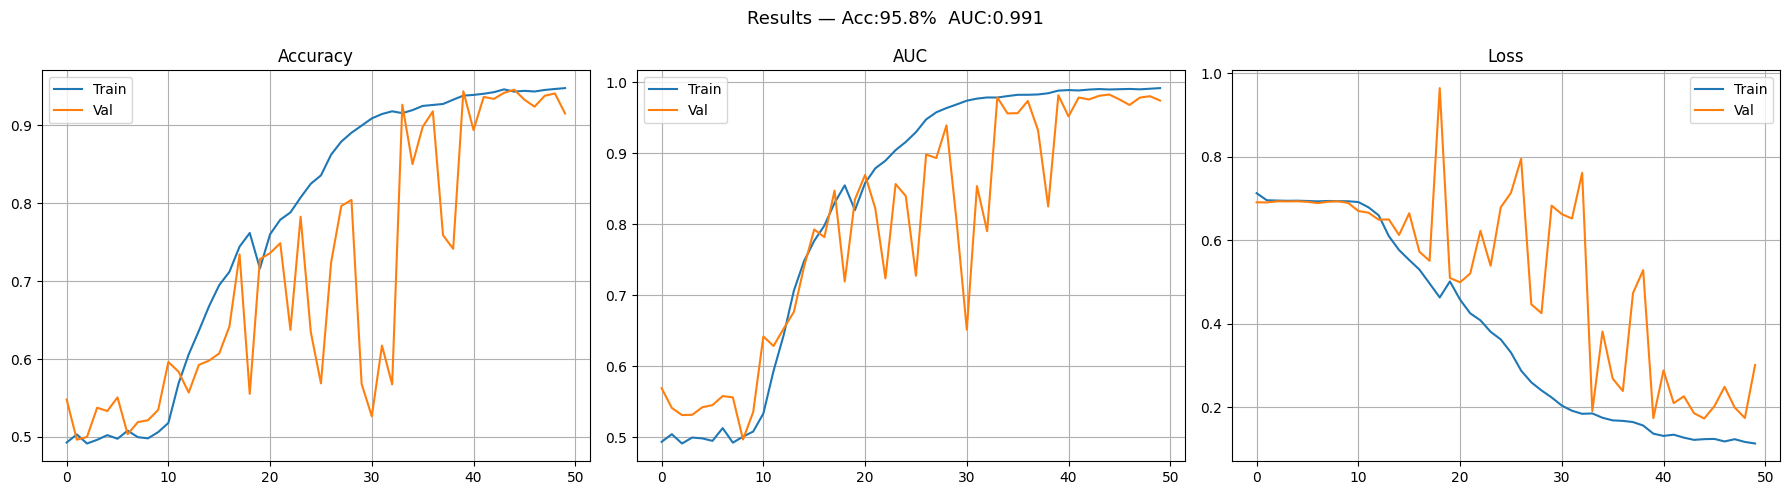

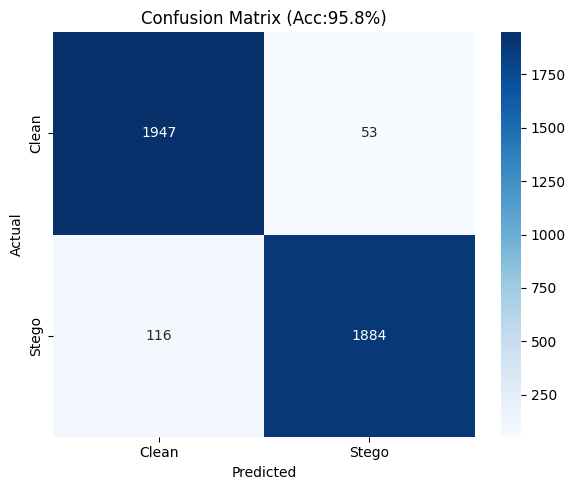


✅ DONE!
  Accuracy : 95.78%
  AUC      : 0.9915


In [40]:
# ══════════════════════════════════════════════
# CELL 11 — SAVE + PLOTS
# ══════════════════════════════════════════════
model.save(MODEL_FINAL)
print(f"Saved → {MODEL_FINAL}")
 
fig, axes = plt.subplots(1,3,figsize=(18,5))
fig.suptitle(f"Results — Acc:{t_acc*100:.1f}%  AUC:{t_auc:.3f}", fontsize=13)
for ax,(k1,k2),title in zip(axes,
    [('accuracy','val_accuracy'),('auc','val_auc'),('loss','val_loss')],
    ['Accuracy','AUC','Loss']):
    ax.plot(history.history[k1],label='Train')
    ax.plot(history.history[k2],label='Val')
    ax.set_title(title); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png',dpi=120); plt.show()
 
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Clean","Stego"], yticklabels=["Clean","Stego"])
plt.title(f"Confusion Matrix (Acc:{t_acc*100:.1f}%)")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png',dpi=120); plt.show()
 
print("\n" + "="*50)
print("✅ DONE!")
print(f"  Accuracy : {t_acc*100:.2f}%")
print(f"  AUC      : {t_auc:.4f}")
print("="*50)